This notebook is dedicated to understanding the reward threshold experiments
Created: 3/6/2022

ran rewthreshold 4-10, integer intervals
for sir2_new, sir2_chunk, sir3, and sir3_chunk models; all 2 stripes



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision #class with the compiled definitions

In [4]:
#other defs not yet in compiled defs
def training_curve_indv(base, specific_file = 'None'):
    #input is the base file with all the model files saved into it
    files = os.listdir(base)
    if specific_file == 'None':
        full_files = [base+f for f in files if 'EpcLog' in f]
    else:
        full_files = [base+f for f in files if 'EpcLog' in f]
        full_files = [f for f in full_files if specific_file in f]
    for f in full_files:
        if 'model0_' in f:
            plt.figure()
            df = pd.read_csv(f, sep = '\t')
            SSE = df['#SSE']
            Epoch = df['|Epoch']
            plt.plot(Epoch,SSE)
            plt.show()
#         elif 'model10_' in f: #this should be fixed now because i fixed the max number of runs. 
#             print('skipping model 10')
        else:
            print(f)
            plt.figure()
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE  = df[2]
            Epoch = df[1]
            plt.plot(Epoch[1:],SSE[1:])
            plt.show()
def training_curve_average(base, specific_file = 'None', additional_title = ''):
    files = os.listdir(base)
    if specific_file == 'None':
        full_files = [base+f for f in files if 'EpcLog' in f]
    else:
        full_files = [base+f for f in files if 'EpcLog' in f]
        full_files = [f for f in full_files if specific_file in f]
    SSE=[]
    Epoch = []
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE.append(df['#SSE'][:500])
            Epoch.append(df['|Epoch'][:500])
            
#         elif 'model10_' in f:
#             print('skipping model 10')
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE.append(df[2][:500])
            #Epoch = df[1]
    SSE_np = np.array(SSE)
    SSE_avg = np.mean(SSE_np, axis = 0)
    plt.plot(Epoch[0],SSE_avg)
    if "StimRange0to45" in f:
        plt.title(f.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'+additional_title)
    else:
        plt.title(f.split('workingmemory')[1].split('/')[1]+additional_title)
    plt.show()
    return SSE_avg,Epoch

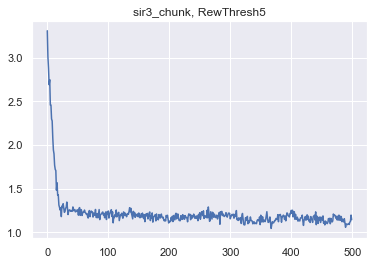

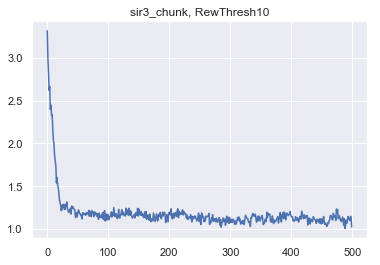

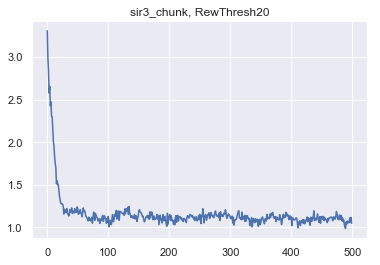

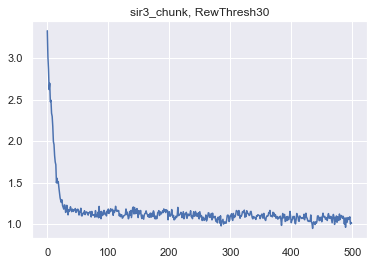

Text(0.5, 0, 'Epochs')

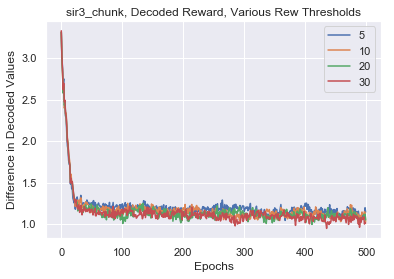

In [4]:
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/"
model_name = base.split('workingmemory/')[1].split('/')[0]
if 'StimRange0to45' in base:
    model_name = model_name+" StimDist 0 to 45"
#rt = [4,5,6,7,8,9,10]
rt = [5,10,20,30]
SSE = []
for r in rt:
    base_file = base+"RewThresh"+str(r)+"/"
    #plt.subplot(2,4,r-3)
    SSE_avg, Epoch = training_curve_average(base_file, additional_title = ', RewThresh'+str(r))
    SSE.append(SSE_avg)
leg = []
for i in range(len(rt)):
        plt.plot(Epoch[0],SSE[i])
for r in rt:
     leg.append(str(r))
plt.legend(leg)
if base.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
    plt.ylabel('Difference in Decoded Values')
else:
    rewardfun = 'Unit Difference'
    plt.ylabel("SSE")
plt.title(model_name +", "+ rewardfun +" Reward, Various Rew Thresholds")
plt.xlabel("Epochs")

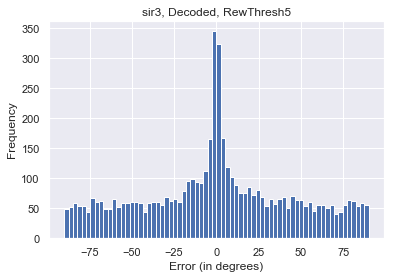

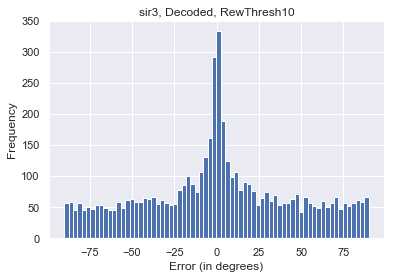

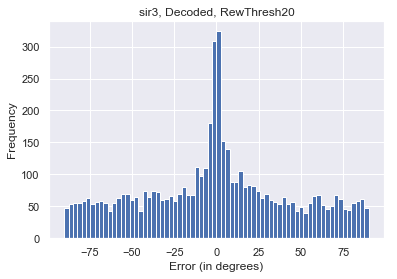

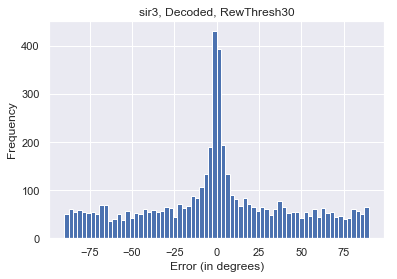

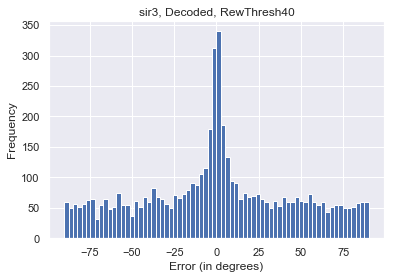

In [9]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/"
#rt = [4,5,6,7,8,9,10]
rt = [5,10,20,30,40]
if "StimRange0to45" in base:
    model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base.split('workingmemory')[1].split('/')[1] 
if base.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
    
for r in rt:
    base_file = base+"RewThresh"+str(r)+"new/"
    files = os.listdir(base_file)
    full_files = [base_file+f for f in files if 'EpcLog' not in f]
    p = Precision()
    err = p.mult_models(full_files)
    plt.figure()

    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+", RewThresh"+str(r))
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')

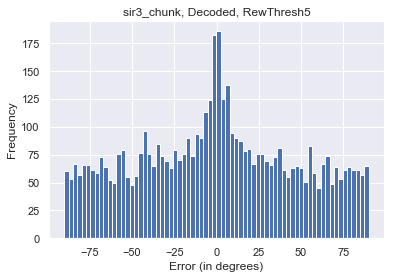

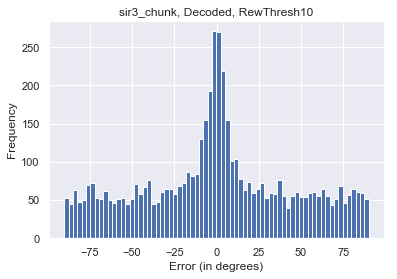

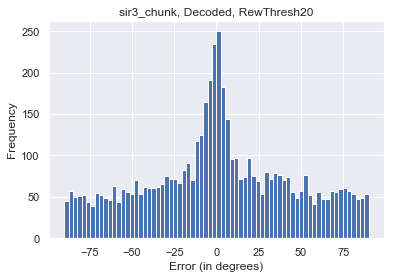

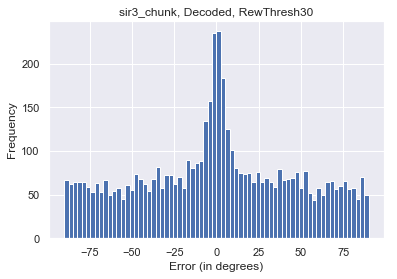

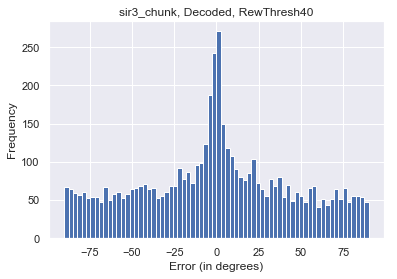

In [8]:
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/"
#rt = [4,5,6,7,8,9,10]
rt = [5,10,20,30,40]
if "StimRange0to45" in base:
    model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base.split('workingmemory')[1].split('/')[1] 
if base.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
    
for r in rt:
    base_file = base+"RewThresh"+str(r)+"new/"
    files = os.listdir(base_file)
    full_files = [base_file+f for f in files if 'EpcLog' not in f]
    p = Precision()
    err = p.mult_models(full_files)
    plt.figure()

    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+", RewThresh"+str(r))
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')

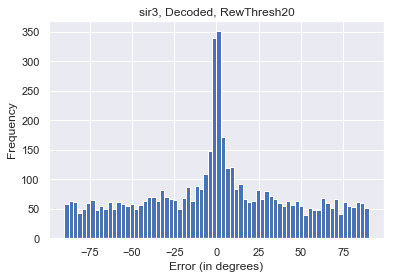

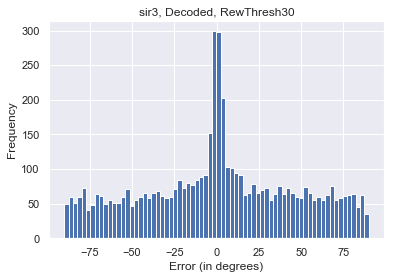

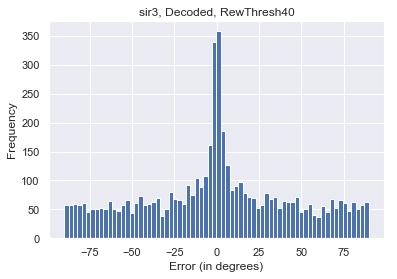

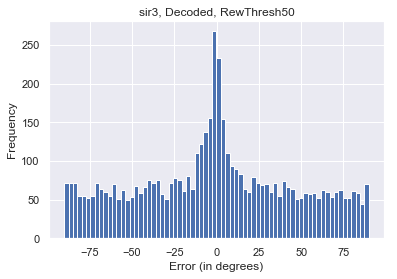

In [7]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/"
#rt = [4,5,6,7,8,9,10]
rt = [20,30,40,50]
if "StimRange0to45" in base:
    model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base.split('workingmemory')[1].split('/')[1] 
if base.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
    
for r in rt:
    base_file = base+"RewThresh"+str(r)+"/"
    files = os.listdir(base_file)
    full_files = [base_file+f for f in files if 'EpcLog' not in f]
    p = Precision()
    err = p.mult_models(full_files)
    plt.figure()

    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+", RewThresh"+str(r))
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')

In [9]:
#for each model type (sir2_new, sir2_chunk, sir3, sir3_chunk and stim type (full range or narrow stim)) - 
#draw the error histogram and the average learning curve
#this should be 8 different types of models for each reward threshold - 4,5,6,7,8,9,10 (i.e. 7 different values)

#maybe its better if we do sir2_new for all reward threhsold values for full range and narrow range. 

In [ ]:
base = "Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/StimRange0to45/2Stripe/hybrid/decodedrew/"
rt = 30
base_file = base+"RewThresh"+str(rt)+"/"
SSE_avg, Epoch = training_curve_average(base_file)
if "StimRange0to45" in base:
    model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base.split('workingmemory')[1].split('/')[1] 
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", RewThresh"+str(r))
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

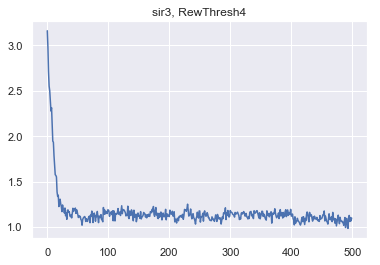

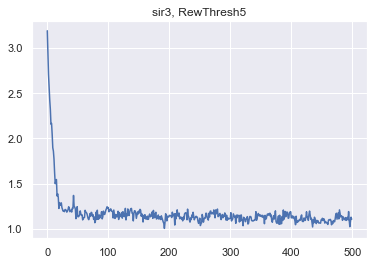

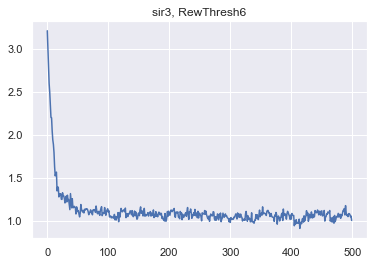

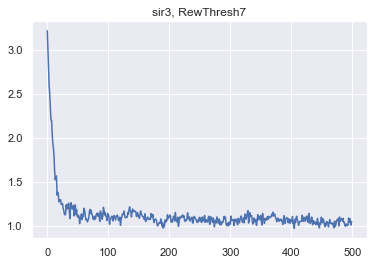

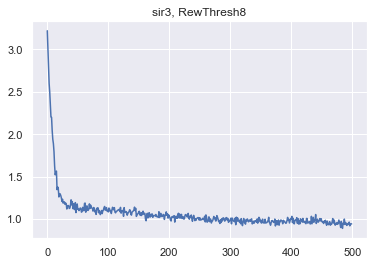

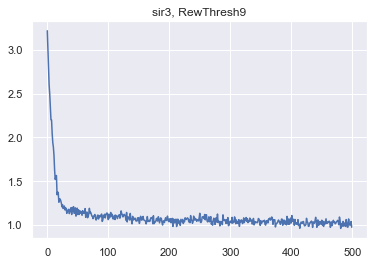

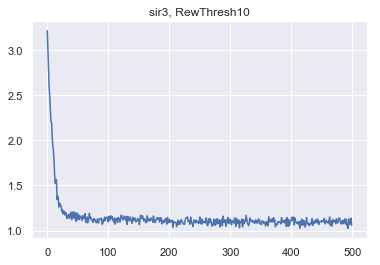

In [31]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/"
rt = [4,5,6,7,8,9,10]
RT = {}
for r in rt:
    base_file = base+"RewThresh"+str(r)+"/"
    #plt.subplot(2,4,r-3)
    SSE_avg, Epoch = training_curve_average(base_file, additional_title = ', RewThresh'+str(r))

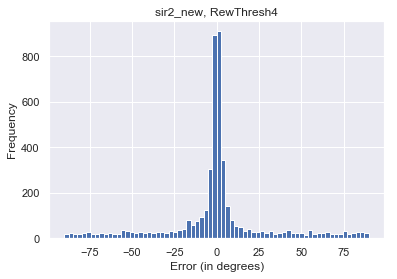

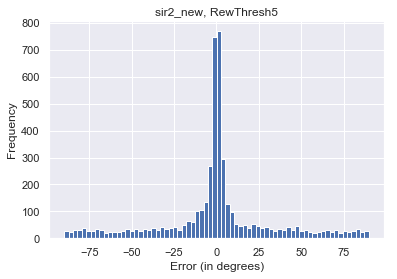

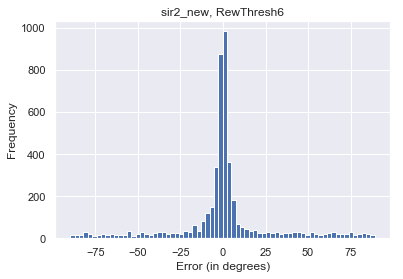

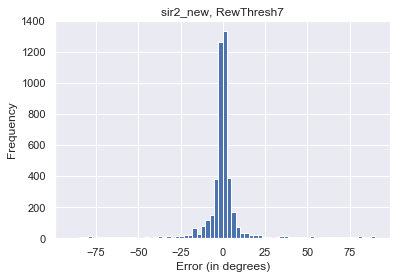

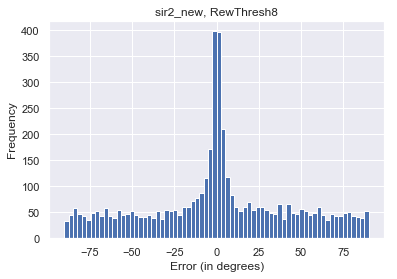

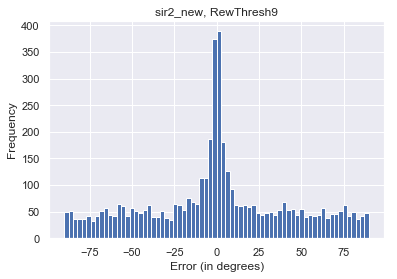

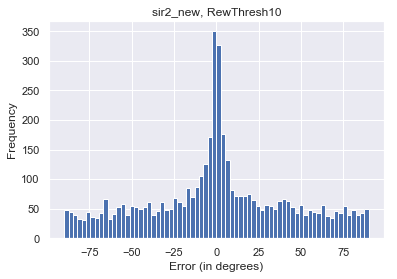

In [25]:
base = "Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/"
rt = [4,5,6,7,8,9,10]
RT = {}
if "StimRange0to45" in base:
    model_name = base.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base.split('workingmemory')[1].split('/')[1] 
for r in rt:
    base_file = base+"RewThresh"+str(r)+"/"
    files = os.listdir(base_file)
    full_files = [base_file+f for f in files if 'EpcLog' not in f]
    p = Precision()
    err = p.mult_models(full_files)
    plt.figure()

    plt.hist(err, bins = 70)
    plt.title(model_name+", RewThresh"+str(r))
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')